In [56]:
from langgraph.graph import StateGraph
from typing import TypedDict

In [57]:
class cricState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    balls_per_boundry: float
    boundry_percent: float
    summary: str

In [58]:
graph = StateGraph(cricState)
print(graph)

In [59]:
def calculate_strike_rate(state: cricState):
    sRate = (state['runs'] / state['balls'] ) * 100

    return {'strike_rate': sRate}

In [60]:
def calculate_balls_per_boundry(state: cricState):
    balls_p_boundry = state['balls'] / (state['fours'] + state['sixes'])

    # state['balls_per_boundry'] = balls_p_boundry
    return {'balls_per_boundry': balls_p_boundry}

In [61]:
def calculate_boundry_percentage(state: cricState):
    bpercent = (( (state['fours'] * 4) + (state['sixes'] * 6)) / state['runs'] ) * 100


    return {'boundry_percent': bpercent}

In [62]:
def generate_summary(state: cricState):
    summary = f"""
    Batsman status are: 
    Strike rate: {state['strike_rate']}. \n
    Balls per Boundry: {state['balls_per_boundry']}. \n
    Boundry percentage: {state['boundry_percent']}. \n
        
"""
    
    state['summary'] = summary
    return state

In [63]:
from langgraph.graph import START, END

In [64]:
graph.add_node('strike_rate', calculate_strike_rate)
graph.add_node('balls_per_boundry', calculate_balls_per_boundry)
graph.add_node('boundry_percentage', calculate_boundry_percentage)
graph.add_node('summary', generate_summary)

graph.add_edge(START, 'strike_rate')
graph.add_edge(START, 'balls_per_boundry')
graph.add_edge(START, 'boundry_percentage')

graph.add_edge('strike_rate', 'summary')
graph.add_edge('balls_per_boundry', 'summary')
graph.add_edge('boundry_percentage', 'summary')

graph.add_edge('summary', END)
    

In [65]:
workflow = graph.compile()

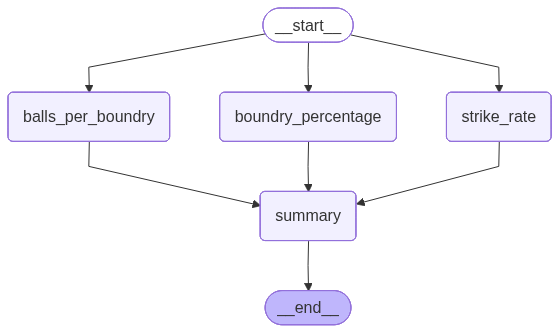

In [66]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

In [67]:
initial_state = {'runs': 39, 'balls': 25, 'fours': 2, 'sixes': 1}
final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 39, 'balls': 25, 'fours': 2, 'sixes': 1, 'strike_rate': 156.0, 'balls_per_boundry': 8.333333333333334, 'boundry_percent': 35.8974358974359, 'summary': '\n    Batsman status are: \n    Strike rate: 156.0. \n\n    Balls per Boundry: 8.333333333333334. \n\n    Boundry percentage: 35.8974358974359. \n\n\n'}
